# 2 &middot; LPT Lightcone Simulation

Notebook 1 painted a static particle set. Here we add **gravity** at the cheapest level:
first-order Lagrangian Perturbation Theory (the Zel'dovich approximation), which displaces
particles from their Lagrangian grid positions $\mathbf q$ to Eulerian positions

$$\mathbf x(a) = \mathbf q + D(a)\,\boldsymbol\Psi(\mathbf q).$$

Instead of one snapshot we build a **lightcone**: `lpt` is asked for `nb_shells` radial shells
and paints each one onto a HEALPix map at its own scale factor. We then

1. compare the measured angular power spectrum $C_\ell$ to linear theory, and
2. recover the small-scale signal by **deconvolving the pixel window** and **subtracting shot
   noise** &mdash; the standard corrections for a particle-sampled field.

## Setup

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import healpy as hp

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Parameters

In [2]:
key = jax.random.PRNGKey(0)
mesh_size = (256, 256, 256)
box_size = (1500.0, 1500.0, 1500.0)   # large box -> shells comfortably above min_width
nside = 256
nb_shells = 3
cosmo = jc.Planck18()
LMAX = 2 * nside                       # stay inside the reliable transform band
ells = jnp.arange(LMAX)

## Initial conditions

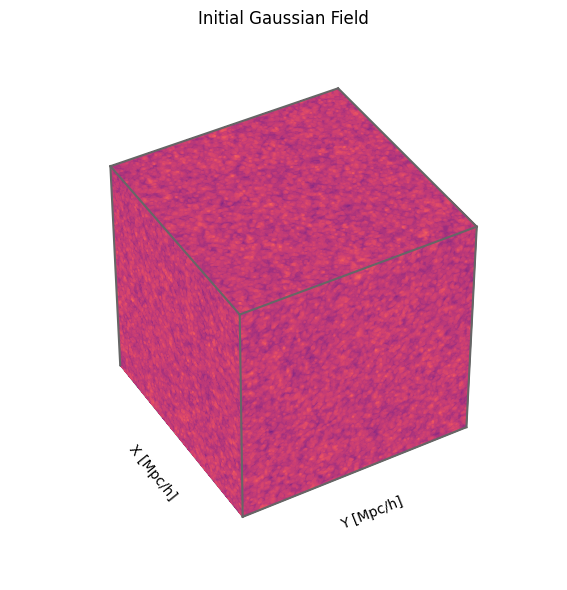

In [3]:
initial_field = jfli.gaussian_initial_conditions(
    key, mesh_size, box_size, cosmo=cosmo, nside=nside,
)
initial_field.show(labels=["X [Mpc/h]", "Y [Mpc/h]", ""], colorbar=False,
                   titles=["Initial Gaussian Field"])

## LPT on a lightcone

Passing `nb_shells` (instead of a scalar `ts`) tells `lpt` to build a lightcone. Under the hood
`jfli.resolve_geometry` slices the comoving volume between the observer and the box boundary
into shells (respecting `min_width`), evaluates the Zel'dovich displacement at each shell's
scale factor, and paints the particles that fall inside it.

We paint with the **`ngp`** scheme: nearest-grid-point has a closed-form HEALPix pixel window,
which is exactly what we will deconvolve below (`bilinear` has no closed form).

In [4]:
spherical_dens, _ = jfli.lpt(
    cosmo, initial_field, nb_shells=nb_shells, order=1,
    painting=jfli.PaintingOptions(target="spherical", scheme="ngp"),
)
a_shells = np.asarray(spherical_dens.scale_factors).ravel()
z_shells = np.asarray(jc.utils.a2z(jnp.asarray(a_shells)))
r_shells = np.asarray(spherical_dens.comoving_centers).ravel()
print(f"output : {type(spherical_dens).__name__}  shape={spherical_dens.shape}  nside={spherical_dens.nside}")
for i, (z, r) in enumerate(zip(z_shells, r_shells)):
    print(f"  shell {i}: z = {z:.3f},  comoving distance = {r:.0f} Mpc/h")

output : SphericalDensity  shape=(3, 49152)  nside=64
  shell 0: z = 0.042,  comoving distance = 125 Mpc/h
  shell 1: z = 0.129,  comoving distance = 375 Mpc/h
  shell 2: z = 0.220,  comoving distance = 625 Mpc/h


### The shells

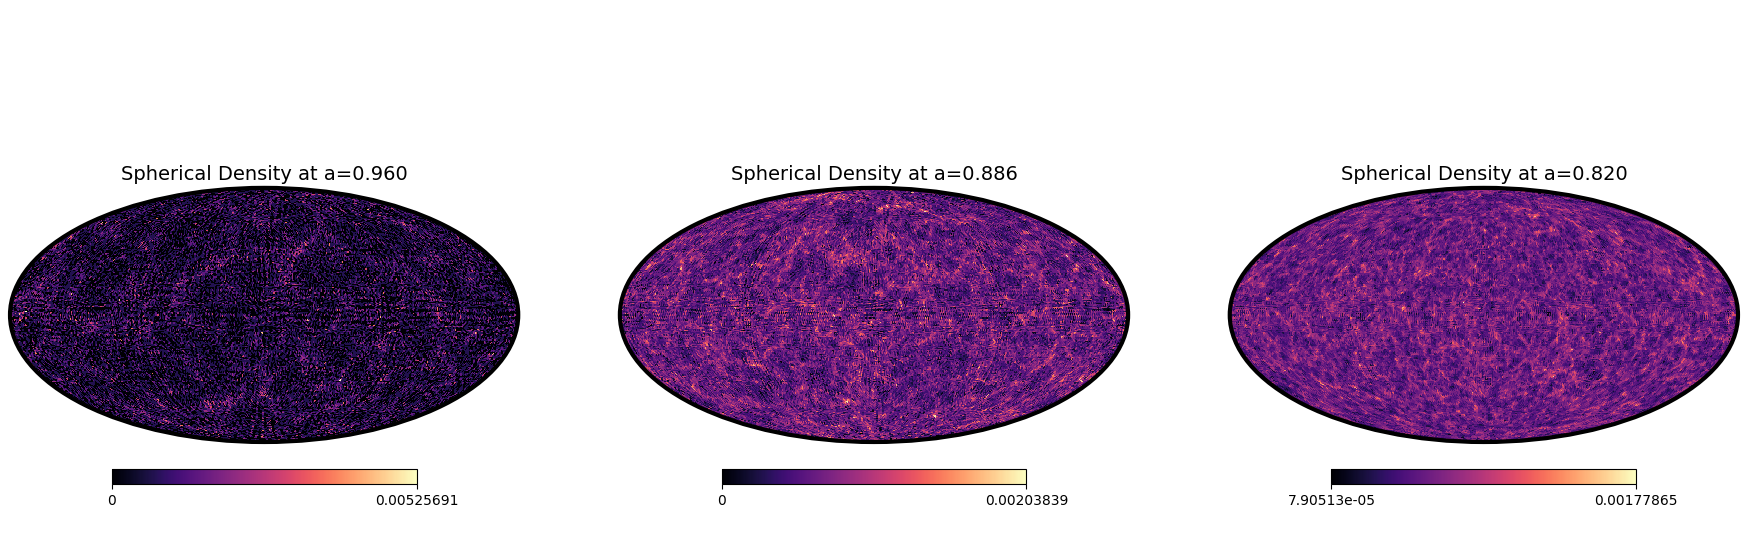

In [5]:
spherical_dens.show(ncols=3)

## Comparison to linear theory

`compute_theory_cl_for_density` predicts the angular power spectrum of each shell from its
redshift kernel. For the measurement we convert the painted **counts** to **overdensity** with
`normalization="per_plane"` &mdash; each shell is normalised by *its own* mean, which is the
right choice on a lightcone where shells at different distances hold different numbers of
particles.

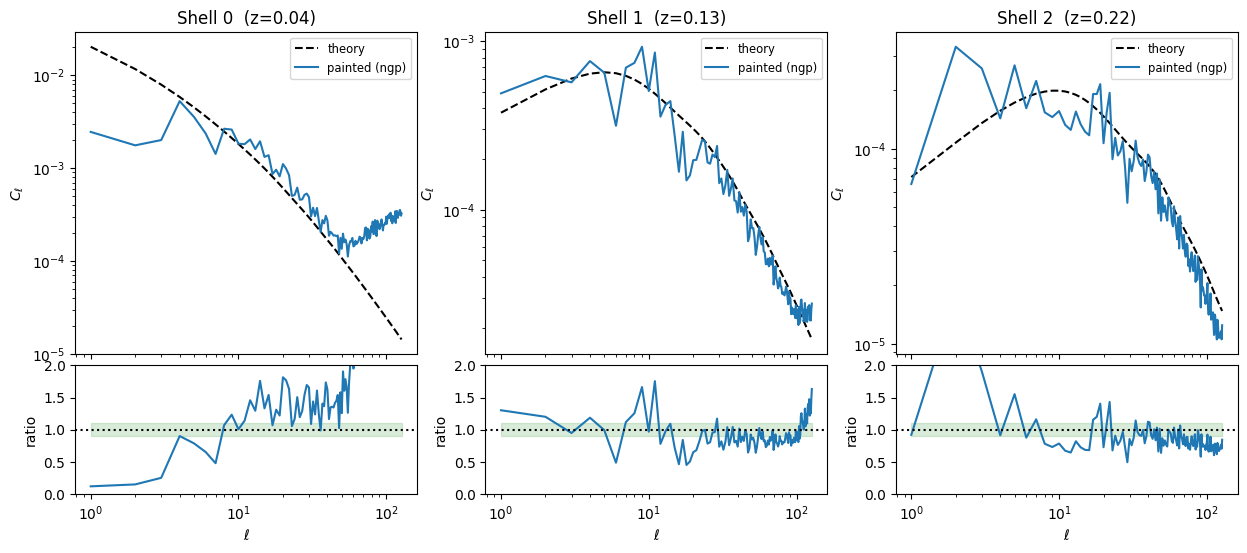

In [6]:
cl_theory = jfli.compute_theory_cl_for_density(
    cosmo, spherical_dens, ells=ells,
    nonlinear_fn=jc.power.linear_matter_power, nz_zmax=1.0,
)
cl_raw = spherical_dens.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(
    method="healpy", lmax=LMAX - 1,
)

th = np.asarray(cl_theory.array)
raw = np.asarray(cl_raw.array)
L = np.arange(1, LMAX)

fig, axes = plt.subplots(2, nb_shells, figsize=(5 * nb_shells, 6), sharex="col",
                         gridspec_kw={"height_ratios": [2.5, 1], "hspace": 0.05})
for i in range(nb_shells):
    axes[0, i].loglog(L, th[i, 1:], "k--", label="theory")
    axes[0, i].loglog(L, raw[i, 1:], color="C0", label="painted (ngp)")
    axes[0, i].set_title(f"Shell {i}  (z={z_shells[i]:.2f})")
    axes[0, i].set_ylabel(r"$C_\ell$"); axes[0, i].legend(fontsize="small")
    axes[1, i].semilogx(L, raw[i, 1:] / th[i, 1:], color="C0")
    axes[1, i].axhline(1, color="k", ls=":"); axes[1, i].set_ylim(0, 2)
    axes[1, i].fill_between(L, 0.9, 1.1, alpha=0.15, color="green")
    axes[1, i].set_xlabel(r"$\ell$"); axes[1, i].set_ylabel("ratio")
plt.tight_layout(); plt.show()

The painted spectrum (blue) **falls below** theory at high $\ell$ (the pixel window
smooths the map) and **plateaus** at a constant floor (Poisson shot noise from sampling the
field with a finite number of particles). Both are sampling artefacts we can remove.

## Deconvolution + shot-noise subtraction

A particle-sampled overdensity shell measures

$$C_\ell^{\rm meas} \;=\; W_\ell^2\,C_\ell^{\rm signal} \;+\; N_{\rm shot},
\qquad N_{\rm shot} = \frac{4\pi}{N_{\rm part}},$$

where $W_\ell$ is the HEALPix pixel window (`hp.pixwin`) and $N_{\rm part}$ is the number of
particles in the shell (full sky).

`SphericalDensity.deconvolve("ngp")` removes one factor of $W_\ell$ at the $a_{\ell m}$ level,
so its spectrum is $C_\ell^{\rm signal} + N_{\rm shot}/W_\ell^2$ &mdash; note the shot-noise
floor is now **amplified** by $1/W_\ell^2$. We therefore subtract $N_{\rm shot}/W_\ell^2$
*after* deconvolving to recover $C_\ell^{\rm signal}$.

In [7]:
# 1. number of particles per shell -> shot-noise floor
N_part = np.asarray(spherical_dens.to(jfli.units.COUNTS).array.sum(axis=-1))
N_shot = 4.0 * np.pi / N_part

# 2. HEALPix pixel window W_ell
Wl = np.asarray(hp.pixwin(nside, lmax=LMAX - 1))

# 3. deconvolve the ngp window (showcases the .deconvolve API), then measure C_ell
deconv = spherical_dens.deconvolve("ngp", lmax=LMAX - 1)
cl_deconv = deconv.to(jfli.units.OVERDENSITY, normalization="per_plane").angular_cl(
    method="healpy", lmax=LMAX - 1,
)
dec = np.asarray(cl_deconv.array)

# 4. subtract the (window-amplified) shot noise
corrected = dec - N_shot[:, None] / np.clip(Wl[None, :], 1e-3, None) ** 2
print("particles / shell:", N_part.astype(int))
print("shot-noise floor :", np.array2string(N_shot, precision=2))

particles / shell: [ 40154 286175 771274]
shot-noise floor : [3.13e-04 4.39e-05 1.63e-05]


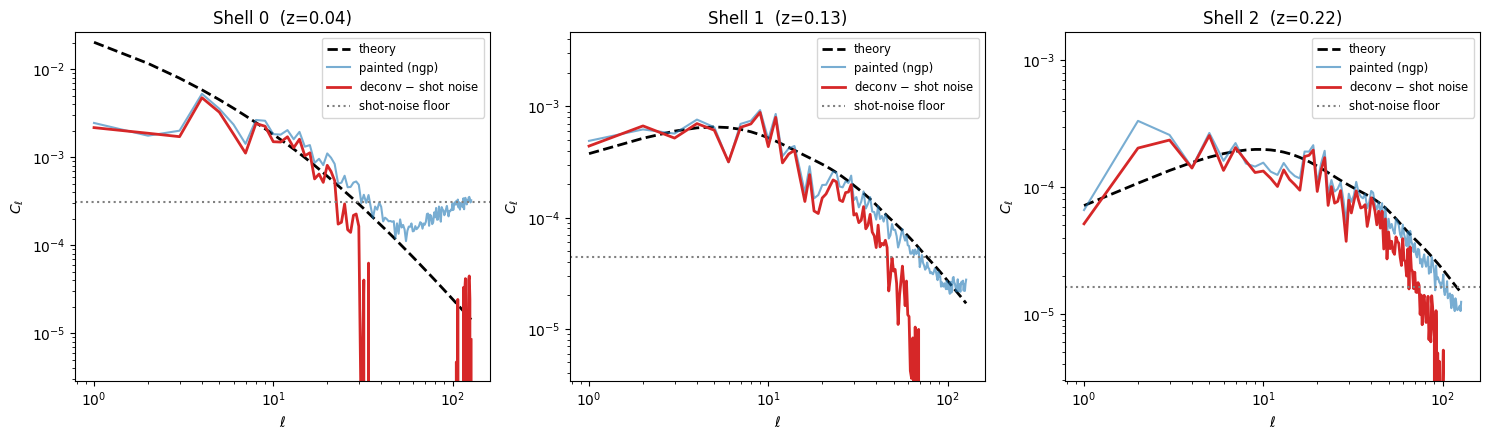

In [8]:
fig, axes = plt.subplots(1, nb_shells, figsize=(5 * nb_shells, 4.5))
for i in range(nb_shells):
    ax = axes[i]
    ax.loglog(L, th[i, 1:], "k--", lw=2, label="theory")
    ax.loglog(L, raw[i, 1:], color="C0", alpha=0.6, label="painted (ngp)")
    ax.loglog(L, corrected[i, 1:], color="C3", lw=2, label="deconv $-$ shot noise")
    ax.axhline(N_shot[i], color="grey", ls=":", label="shot-noise floor")
    ax.set_title(f"Shell {i}  (z={z_shells[i]:.2f})")
    ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$C_\ell$")
    ax.set_ylim(th[i, 1:].min() * 0.2, raw[i, 1:].max() * 5)
    ax.legend(fontsize="small")
plt.tight_layout(); plt.show()

The corrected spectrum (red) sits on theory across the scales where the **signal exceeds
the shot-noise floor** (grey dotted), then drops out once it doesn't &mdash; on a log axis the
curve simply ends where the subtraction goes negative. The outer shell holds the most particles
and stays clean to the highest $\ell$; the inner shells are shot-noise limited at this
resolution. Increasing `mesh_size` / `nside` (the production setting) pushes the clean range to
smaller scales.

**Next:** [03 &middot; PM Simulation](03-PM-Simulation.ipynb) replaces the Zel'dovich kick with
a full N-body integration, and [07 &middot; Lensing](../2-advanced-usage/07-Lensing.ipynb)
turns these shells into weak-lensing maps.